In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Beijing_Multisite_air_Quality_data.csv to Beijing_Multisite_air_Quality_data.csv


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 17 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   year     420768 non-null  int64  
 1   month    420768 non-null  int64  
 2   day      420768 non-null  int64  
 3   hour     420768 non-null  int64  
 4   PM2.5    412029 non-null  float64
 5   PM10     414319 non-null  float64
 6   SO2      411747 non-null  float64
 7   NO2      408652 non-null  float64
 8   CO       400067 non-null  float64
 9   O3       407491 non-null  float64
 10  TEMP     420370 non-null  float64
 11  PRES     420375 non-null  float64
 12  DEWP     420365 non-null  float64
 13  RAIN     420378 non-null  float64
 14  wd       418946 non-null  object 
 15  WSPM     420450 non-null  float64
 16  station  420768 non-null  object 
dtypes: float64(11), int64(4), object(2)
memory usage: 54.6+ MB
None

Contoh Data Awal:
   year  month  day  hour  PM2.5  PM10   

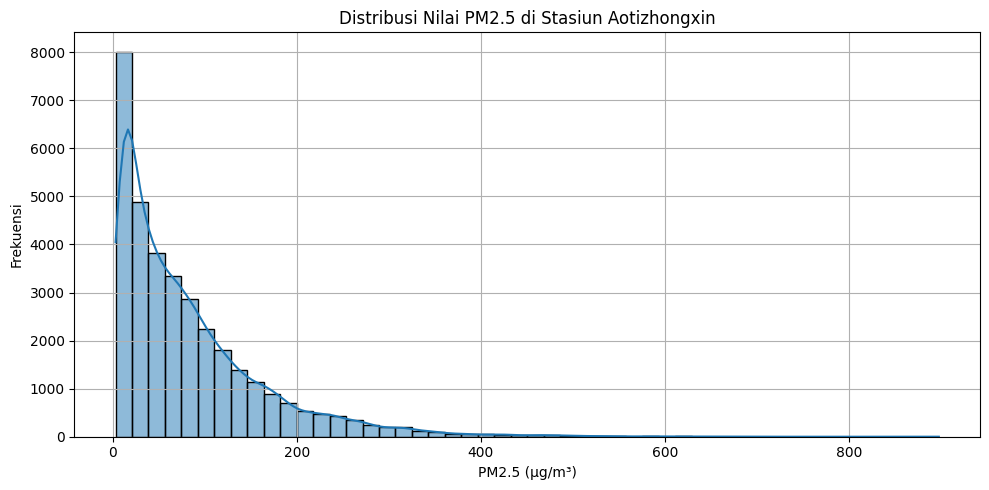


Jumlah Missing Value per Kolom:
CO       1776
O3       1719
NO2      1023
SO2       935
PM2.5     925
PM10      718
wd         81
TEMP       20
PRES       20
DEWP       20
RAIN       20
WSPM       14
dtype: int64


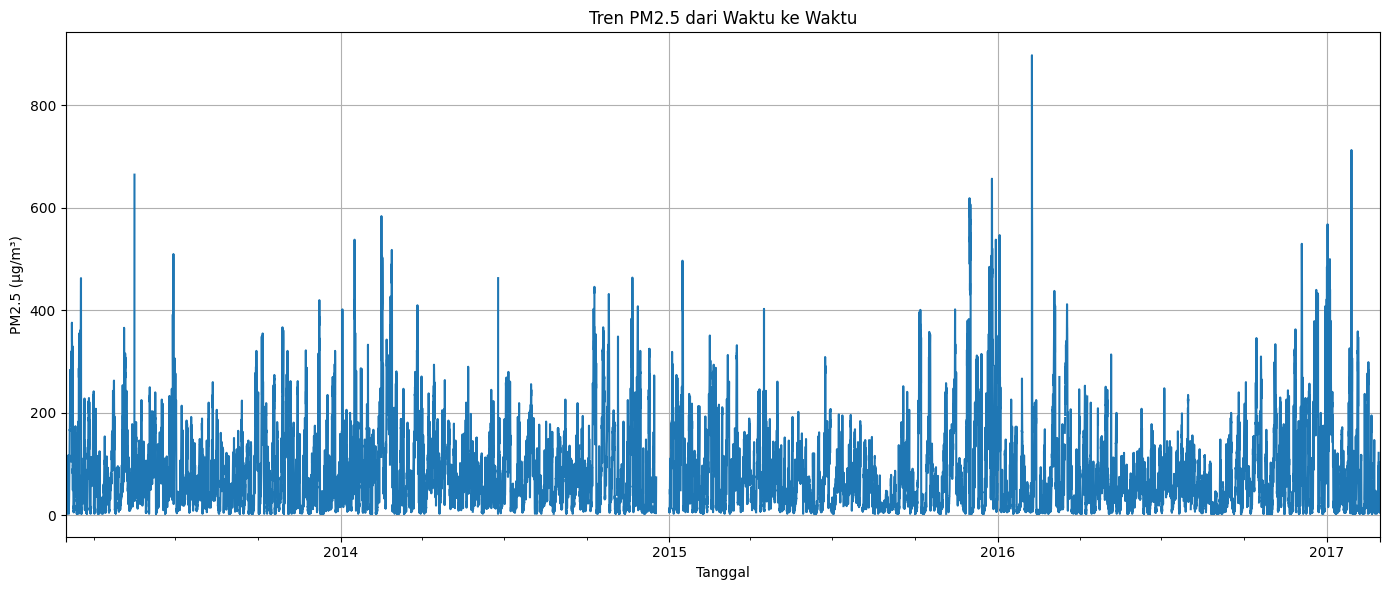

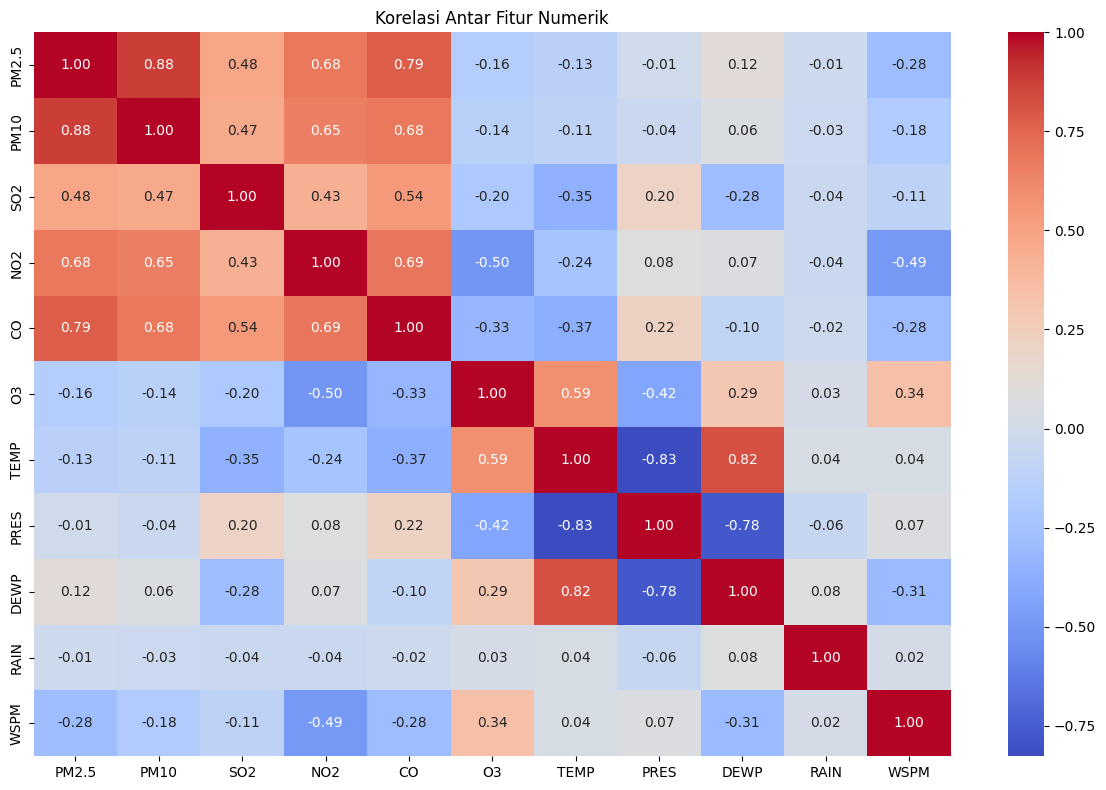

In [ ]:
# ==============================
# 1. Import Library
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agar grafik muncul langsung di notebook
%matplotlib inline

# ==============================
# 2. Load Dataset
# ==============================
# Ganti path ini sesuai lokasi file
file_path = 'Beijing_Multisite_air_Quality_data.csv'
df = pd.read_csv(file_path)

# ==============================
# 3. Cek Struktur Dataset
# ==============================
print("Informasi Dataset:")
print(df.info())
print("\nContoh Data Awal:")
print(df.head())

# ==============================
# 4. Filter Data Berdasarkan Satu Stasiun
# ==============================
# Kita pilih stasiun 'Aotizhongxin' untuk analisis
df_filtered = df[df['station'] == 'Aotizhongxin'].copy()

# ==============================
# 5. Buat Kolom Datetime dan Jadikan Index
# ==============================
# Gabungkan kolom waktu menjadi satu datetime
df_filtered['datetime'] = pd.to_datetime(df_filtered[['year', 'month', 'day', 'hour']])
df_filtered.set_index('datetime', inplace=True)

# ==============================
# 6. Visualisasi Distribusi PM2.5
# ==============================
plt.figure(figsize=(10, 5))
sns.histplot(df_filtered['PM2.5'].dropna(), bins=50, kde=True)
plt.title('Distribusi Nilai PM2.5 di Stasiun Aotizhongxin')
plt.xlabel('PM2.5 (μg/m³)')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# 7. Cek Missing Values
# ==============================
print("\nJumlah Missing Value per Kolom:")
missing = df_filtered.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

# ==============================
# 8. Visualisasi Tren Waktu PM2.5
# ==============================
plt.figure(figsize=(14, 6))
df_filtered['PM2.5'].plot()
plt.title('Tren PM2.5 dari Waktu ke Waktu')
plt.ylabel('PM2.5 (μg/m³)')
plt.xlabel('Tanggal')
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# 9. Korelasi Antar Fitur Numerik
# ==============================
# Pilih kolom numerik yang penting
numerical_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
corr = df_filtered[numerical_cols].corr()

# Tampilkan heatmap korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.show()


In [ ]:
# Preprocessing + Feature Selection
# ==============================
# 1. Import Library
# ==============================
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 2. Load dan Filter Data (Stasiun Aotizhongxin)
# ==============================
df = pd.read_csv('Beijing_Multisite_air_Quality_data.csv')
df_filtered = df[df['station'] == 'Aotizhongxin'].copy()
df_filtered['datetime'] = pd.to_datetime(df_filtered[['year', 'month', 'day', 'hour']])
df_filtered.set_index('datetime', inplace=True)

# ==============================
# 3. Feature Selection (berdasarkan korelasi)
# ==============================
selected_features = ['PM10', 'CO', 'NO2', 'SO2', 'DEWP']
target_column = 'PM2.5'
df_model = df_filtered[selected_features + [target_column]].copy()

# ==============================
# 4. Tangani Missing Value
# ==============================
df_model.fillna(method='ffill', inplace=True)  # Isi dengan data sebelumnya
df_model.dropna(inplace=True)  # Hapus baris yang masih kosong

# ==============================
# 5. Normalisasi (Min-Max Scaling)
# ==============================
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_model)

# ==============================
# 6. Membuat Sequence Data untuk LSTM
# ==============================
window_size = 24  # menggunakan 24 jam data sebelumnya
X, y = [], []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i - window_size:i, :-1])  # Semua fitur kecuali target
    y.append(scaled_data[i, -1])  # Target: PM2.5

X = np.array(X)
y = np.array(y)

# ==============================
# 7. Train-Test Split
# ==============================
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

# ==============================
# 8. Cek Bentuk Data
# ==============================
print("X shape (all):", X.shape)
print("y shape (all):", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X shape (all): (35040, 24, 5)
y shape (all): (35040,)
X_train shape: (28032, 24, 5)
X_test shape: (7008, 24, 5)


/tmp/ipython-input-3-1690153613.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_model.fillna(method='ffill', inplace=True)  # Isi dengan data sebelumnya


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0031 - mae: 0.0375 - val_loss: 0.0020 - val_mae: 0.0249
Epoch 2/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0014 - mae: 0.0251 - val_loss: 0.0018 - val_mae: 0.0227
Epoch 3/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0014 - mae: 0.0245 - val_loss: 0.0021 - val_mae: 0.0264
Epoch 4/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0012 - mae: 0.0234 - val_loss: 0.0021 - val_mae: 0.0245
Epoch 5/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0013 - mae: 0.0235 - val_loss: 0.0017 - val_mae: 0.0212
Epoch 6/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0011 - mae: 0.0222 - val_loss: 0.0017 - val_mae: 0.0240
Epoch 7/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0011 - mae: 0.0222 - val_loss: 0.0017 - val_mae: 0.0217
Epoch 8/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 9.9667e-04 - mae: 0.0218 - val_loss: 0.0017 - val_mae: 0.0229
Epoch 9/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 4s 

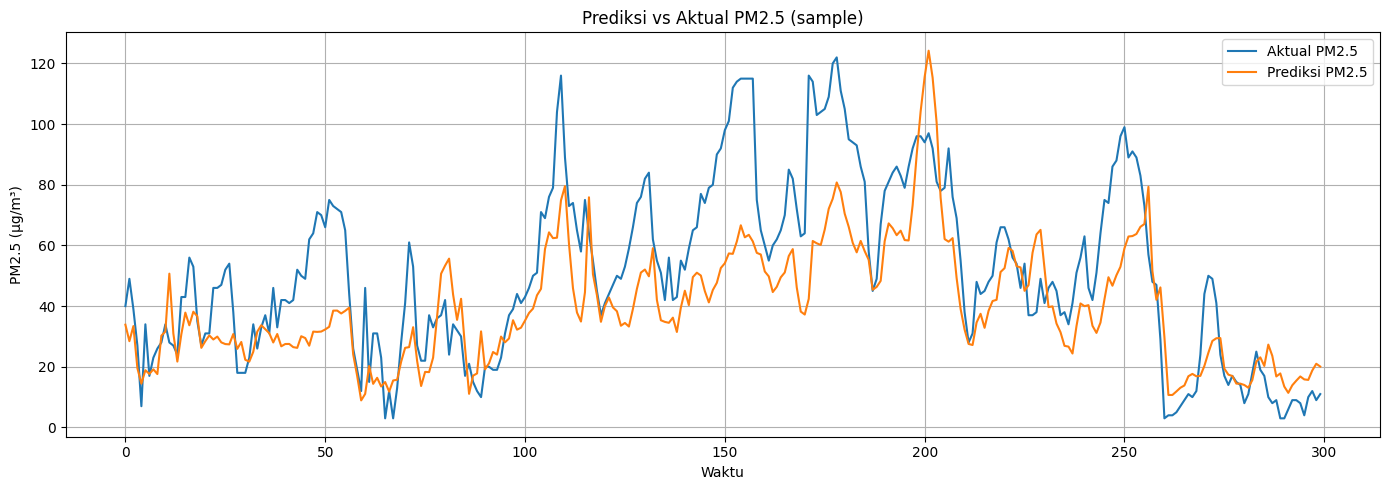

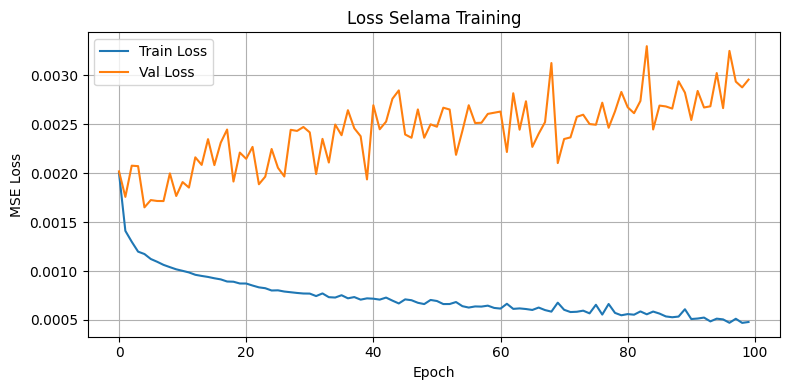

In [ ]:
# LSTM untuk Prediksi PM2.5 + Evaluasi
# ==============================
# 1. Import Library untuk Model
# ==============================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

# ==============================
# 2. Membangun Model LSTM
# ==============================
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))  # Output satu nilai PM2.5
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ==============================
# 3. Training Model
# ==============================
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ==============================
# 4. Evaluasi Model
# ==============================

# Prediksi data uji
y_pred = model.predict(X_test)

# Invers transform dari skala MinMax (target)
y_test_inv = scaler.inverse_transform(
    np.hstack((np.zeros((y_test.shape[0], len(selected_features))), y_test.reshape(-1, 1)))
)[:, -1]

y_pred_inv = scaler.inverse_transform(
    np.hstack((np.zeros((y_pred.shape[0], len(selected_features))), y_pred))
)[:, -1]

# Hitung metrik regresi
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"\n📊 Hasil Evaluasi:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# ==============================
# 5. Visualisasi Hasil Prediksi
# ==============================
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv[:300], label='Aktual PM2.5')
plt.plot(y_pred_inv[:300], label='Prediksi PM2.5')
plt.title('Prediksi vs Aktual PM2.5 (sample)')
plt.xlabel('Waktu')
plt.ylabel('PM2.5 (μg/m³)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# 6. Visualisasi Loss Selama Training
# ==============================
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Selama Training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
# K-Fold Time Series LSTM

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# 5-fold time series
tscv = TimeSeriesSplit(n_splits=5)

# Simpan hasil metrik
mae_scores_lstm = []
mse_scores_lstm = []
r2_scores_lstm = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"\n🔁 Fold {fold+1}")

    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    # Model LSTM
    model = Sequential()
    model.add(LSTM(64, input_shape=(X.shape[1], X.shape[2])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    # Early stopping
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    model.fit(X_train_fold, y_train_fold,
              epochs=100,
              batch_size=32,
              validation_split=0.1,
              callbacks=[es],
              verbose=0)

    # Prediksi
    y_pred = model.predict(X_test_fold)

    # Inverse transform target
    y_test_inv = scaler.inverse_transform(
        np.hstack((np.zeros((len(y_test_fold), len(selected_features))), y_test_fold.reshape(-1,1)))
    )[:, -1]
    y_pred_inv = scaler.inverse_transform(
        np.hstack((np.zeros((len(y_pred), len(selected_features))), y_pred))
    )[:, -1]

    # Evaluasi
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mse = mean_squared_error(y_test_inv, y_pred_inv)
    r2 = r2_score(y_test_inv, y_pred_inv)

    print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, R²: {r2:.4f}")
    mae_scores_lstm.append(mae)
    mse_scores_lstm.append(mse)
    r2_scores_lstm.append(r2)

# Rata-rata
print("\n📊 Rata-rata K-Fold LSTM (Epoch 100):")
print(f"MAE: {np.mean(mae_scores_lstm):.2f}")
print(f"MSE: {np.mean(mse_scores_lstm):.2f}")
print(f"R² : {np.mean(r2_scores_lstm):.4f}")



🔁 Fold 1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE: 25.56, MSE: 1413.01, R²: 0.8027

🔁 Fold 2


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MAE: 21.96, MSE: 1020.93, R²: 0.8461

🔁 Fold 3


...

183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE: 22.84, MSE: 977.70, R²: 0.7462

🔁 Fold 4


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE: 20.58, MSE: 1429.01, R²: 0.8491

🔁 Fold 5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MAE: 17.18, MSE: 836.60, R²: 0.8951

📊 Rata-rata K-Fold LSTM (Epoch 100):
MAE: 21.62
MSE: 1135.45
R² : 0.8279


In [ ]:
# Model RNN + Evaluasi

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Bangun Model RNN ===
rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping
early_stop_rnn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# === Training ===
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

# === Evaluasi ===
y_pred_rnn = rnn_model.predict(X_test)

mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
mse_rnn = mean_squared_error(y_test, y_pred_rnn)
r2_rnn = r2_score(y_test, y_pred_rnn)

print("📊 Evaluasi Model RNN:")
print("MAE:", round(mae_rnn * 100, 2))
print("MSE:", round(mse_rnn * 10000, 2))
print("R² Score:", round(r2_rnn, 4))


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0068 - mae: 0.0511 - val_loss: 0.0012 - val_mae: 0.0251
Epoch 2/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0017 - mae: 0.0282 - val_loss: 9.9942e-04 - val_mae: 0.0204
Epoch 3/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0016 - mae: 0.0269 - val_loss: 9.8963e-04 - val_mae: 0.0205
Epoch 4/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0016 - mae: 0.0261 - val_loss: 0.0011 - val_mae: 0.0214
Epoch 5/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0015 - mae: 0.0260 - val_loss: 0.0010 - val_mae: 0.0219
Epoch 6/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0015 - mae: 0.0253 - val_loss: 9.4248e-04 - val_mae: 0.0196
Epoch 7/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0014 - mae: 0.0246 - val_loss: 0.0010 - val_mae: 0.0211
Epoch 8/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0014 - mae: 0.0246 - val_loss: 8.9053e-04 - val_mae: 0.0192
Epoch 9/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 

In [ ]:
# K-Fold TimeSeries untuk RNN

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores_rnn = []
mse_scores_rnn = []
r2_scores_rnn = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"\n🔁 Fold {fold+1}")

    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    model_rnn = Sequential([
        SimpleRNN(64, activation='tanh', input_shape=(X.shape[1], X.shape[2])),
        Dense(1)
    ])
    model_rnn.compile(optimizer=Adam(), loss='mse')

    # Early stopping
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    model_rnn.fit(X_train_fold, y_train_fold,
                  epochs=100,
                  batch_size=64,
                  validation_split=0.1,
                  callbacks=[es],
                  verbose=0)

    # Prediksi
    y_pred = model_rnn.predict(X_test_fold)

    # Inverse transform target
    y_test_inv = scaler.inverse_transform(
        np.hstack((np.zeros((len(y_test_fold), len(selected_features))), y_test_fold.reshape(-1, 1)))
    )[:, -1]
    y_pred_inv = scaler.inverse_transform(
        np.hstack((np.zeros((len(y_pred), len(selected_features))), y_pred))
    )[:, -1]

    # Evaluasi
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mse = mean_squared_error(y_test_inv, y_pred_inv)
    r2 = r2_score(y_test_inv, y_pred_inv)

    print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, R²: {r2:.4f}")
    mae_scores_rnn.append(mae)
    mse_scores_rnn.append(mse)
    r2_scores_rnn.append(r2)

# Rata-rata
print("\n📊 Rata-rata K-Fold RNN (Epoch 100):")
print(f"MAE: {np.mean(mae_scores_rnn):.2f}")
print(f"MSE: {np.mean(mse_scores_rnn):.2f}")
print(f"R² : {np.mean(r2_scores_rnn):.4f}")



🔁 Fold 1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
MAE: 26.23, MSE: 1460.15, R²: 0.7961

🔁 Fold 2


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MAE: 23.71, MSE: 1167.26, R²: 0.8241

🔁 Fold 3


...

183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
MAE: 20.61, MSE: 937.15, R²: 0.7568

🔁 Fold 4


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MAE: 28.08, MSE: 1828.32, R²: 0.8070

🔁 Fold 5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
MAE: 17.18, MSE: 738.56, R²: 0.9074

📊 Rata-rata K-Fold RNN (Epoch 100):
MAE: 23.16
MSE: 1226.29
R² : 0.8183


/tmp/ipython-input-9-1775255193.py:46: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


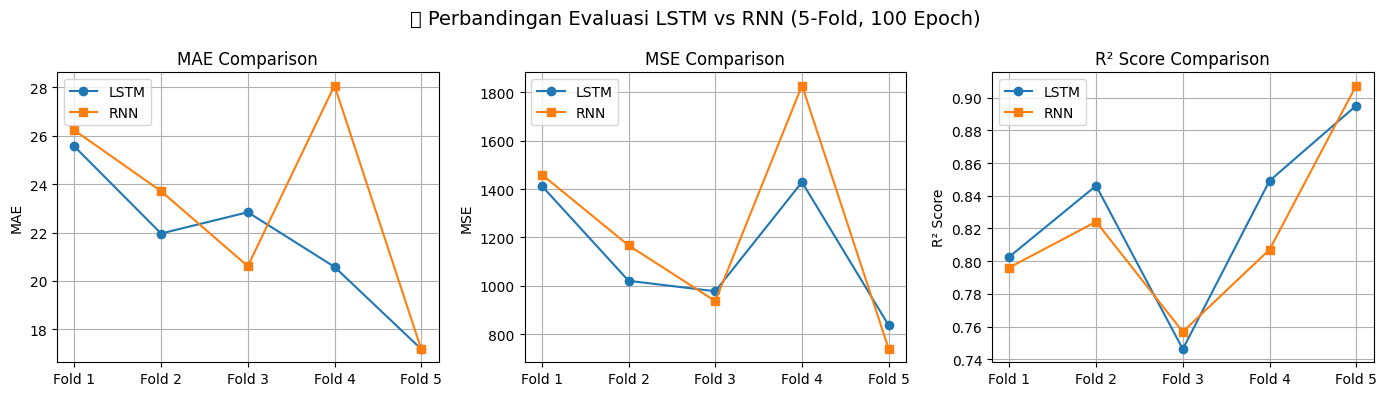

In [ ]:
# visualisasi perbandingan hasil K-Fold TimeSeries antara LSTM vs RNN

import matplotlib.pyplot as plt
import numpy as np

# === Nilai dari hasil 5-Fold Evaluasi LSTM dan RNN  ===
mae_rnn = [26.23, 23.71, 20.61, 28.08, 17.18]
mse_rnn = [1460.15, 1167.26, 937.15, 1828.32, 738.56]
r2_rnn  = [0.7961, 0.8241, 0.7568, 0.8070, 0.9074]

mae_lstm = [25.56, 21.96, 22.84, 20.58, 17.18]
mse_lstm = [1413.01, 1020.93, 977.70, 1429.01, 836.60]
r2_lstm  = [0.8027, 0.8461, 0.7462, 0.8491, 0.8951]

folds = [f'Fold {i+1}' for i in range(5)]

# === Plot MAE ===
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.plot(folds, mae_lstm, marker='o', label='LSTM')
plt.plot(folds, mae_rnn, marker='s', label='RNN')
plt.title('MAE Comparison')
plt.ylabel('MAE')
plt.grid(True)
plt.legend()

# === Plot MSE ===
plt.subplot(1, 3, 2)
plt.plot(folds, mse_lstm, marker='o', label='LSTM')
plt.plot(folds, mse_rnn, marker='s', label='RNN')
plt.title('MSE Comparison')
plt.ylabel('MSE')
plt.grid(True)
plt.legend()

# === Plot R² ===
plt.subplot(1, 3, 3)
plt.plot(folds, r2_lstm, marker='o', label='LSTM')
plt.plot(folds, r2_rnn, marker='s', label='RNN')
plt.title('R² Score Comparison')
plt.ylabel('R² Score')
plt.grid(True)
plt.legend()

plt.suptitle('📊 Perbandingan Evaluasi LSTM vs RNN (5-Fold, 100 Epoch)', fontsize=14)
plt.tight_layout()
plt.show()


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 2/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0012 - val_loss: 9.4498e-04
Epoch 3/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 9.6971e-04 - val_loss: 8.5906e-04
Epoch 4/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.2346e-04 - val_loss: 8.4094e-04
Epoch 5/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 9.0723e-04 - val_loss: 7.9418e-04
Epoch 6/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.9846e-04 - val_loss: 8.2253e-04
Epoch 7/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.6483e-04 - val_loss: 8.2726e-04
Epoch 8/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.4470e-04 - val_loss: 7.7889e-04
Epoch 9/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 8.5310e-04 - val_loss: 7.8204e-04
Epoch 10/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 9.0424e-04 - val_loss: 7.7305e-04
Epoch 11/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.8259e-04 

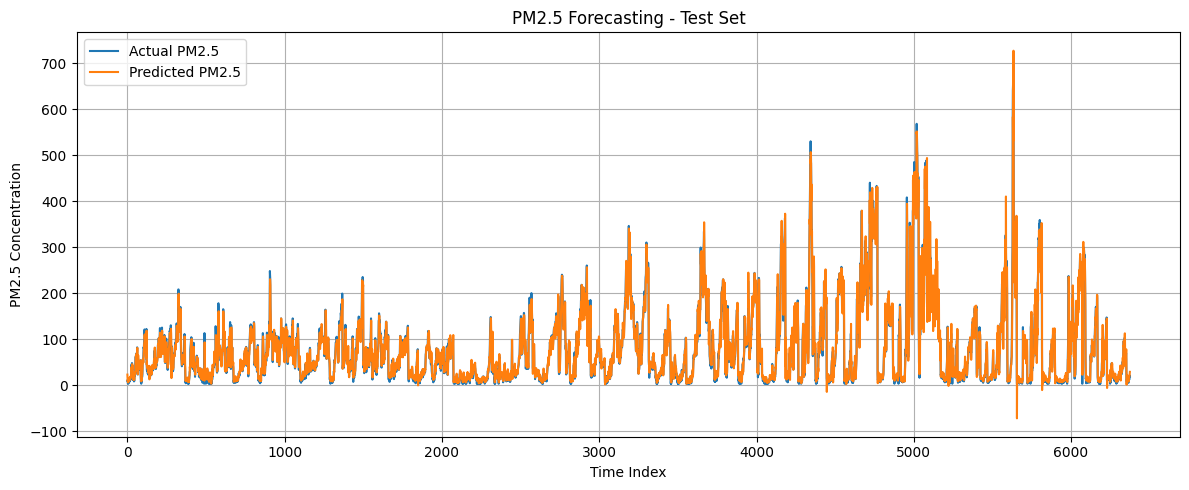

In [ ]:
#LSTM RNN Forecasting
# === KODE LENGKAP TESTING & FORECASTING LSTM UNTUK PREDIKSI PM2.5 ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# === Load Dataset ===
df = pd.read_csv("Beijing_Multisite_air_Quality_data.csv")
df = df[df['station'] == 'Aotizhongxin']  # contoh: ambil satu stasiun biar stabil

# === Pilih Fitur ===
selected_features = ['PM10', 'SO2', 'NO2', 'CO', 'O3']
target_feature = 'PM2.5'
all_features = selected_features + [target_feature]

# === Bersihkan Data ===
df_clean = df[all_features].dropna()

# === Normalisasi ===
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_clean)

# === Sequence Window Function ===
def create_sequences(data, target_index, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])
        y.append(data[i, target_index])
    return np.array(X), np.array(y)

window_size = 24
X_all, y_all = create_sequences(scaled_data, target_index=len(selected_features), window_size=window_size)

# === Split 80% Train - 20% Test ===
split_index = int(len(X_all) * 0.8)
X_train, X_test = X_all[:split_index], X_all[split_index:]
y_train, y_test = y_all[:split_index], y_all[split_index:]

# === Bangun Model LSTM ===
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# === Training Model ===
model.fit(X_train, y_train,
          epochs=100,
          batch_size=64,
          validation_split=0.1,
          callbacks=[es],
          verbose=1)

# === Prediksi Testing ===
y_pred = model.predict(X_test)

# === Inverse Transform ===
def inverse_scale(y_scaled):
    dummy = np.zeros((len(y_scaled), len(selected_features) + 1))
    dummy[:, -1] = y_scaled.reshape(-1)
    return scaler.inverse_transform(dummy)[:, -1]

y_pred_inv = inverse_scale(y_pred)
y_test_inv = inverse_scale(y_test)

# === Evaluasi ===
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"\n📊 Hasil Evaluasi Testing (LSTM):")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# === Visualisasi ===
plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label='Actual PM2.5')
plt.plot(y_pred_inv, label='Predicted PM2.5')
plt.title("PM2.5 Forecasting - Test Set")
plt.xlabel("Time Index")
plt.ylabel("PM2.5 Concentration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM

# Load data
df = pd.read_csv('Beijing_Multisite_air_Quality_data.csv')
df = df[df['station'] == 'Aotizhongxin']
df = df[['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']]
df = df.dropna()
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.sort_values('datetime', inplace=True)

# Fitur dan target
features = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
target = 'PM2.5'

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features + [target]])

# Windowing
window_size = 24
X, y = [], []
for i in range(len(scaled_data) - window_size):
    X.append(scaled_data[i:i + window_size, :-1])
    y.append(scaled_data[i + window_size, -1])
X, y = np.array(X), np.array(y)

# Split train-test
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

X_forecast = X_test[-1].reshape(1, window_size, len(features))

# SimpleRNN
model_rnn = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(window_size, len(features))),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)
rnn_pred_scaled = model_rnn.predict(X_forecast)

# LSTM
model_lstm = Sequential([
    LSTM(64, activation='tanh', input_shape=(window_size, len(features))),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0)
lstm_pred_scaled = model_lstm.predict(X_forecast)

# Inverse transform
zeros_padding = np.zeros((1, len(features)))
rnn_pred = scaler.inverse_transform(np.hstack((zeros_padding, rnn_pred_scaled)))[:, -1][0]
lstm_pred = scaler.inverse_transform(np.hstack((zeros_padding, lstm_pred_scaled)))[:, -1][0]
y_actual = scaler.inverse_transform(np.hstack((zeros_padding, y_test[-1].reshape(1, 1))))[:, -1][0]

rnn_error = abs(rnn_pred - y_actual)
lstm_error = abs(lstm_pred - y_actual)

print("✓ Prediksi PM2.5 berikutnya:")
print(f"SimpleRNN: {rnn_pred:.2f}")
print(f"LSTM     : {lstm_pred:.2f}")
print(f"PM2.5 aktual: {y_actual:.2f}")
print(f"Error RNN : {rnn_error:.2f}")
print(f"Error LSTM: {lstm_error:.2f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
✓ Prediksi PM2.5 berikutnya:
SimpleRNN: 39.12
LSTM     : 25.27
PM2.5 aktual: 19.00
Error RNN : 20.12
Error LSTM: 6.27
